# Model Building - Naive Bayes Classifier
In this part, we move from text features to actual learning. After converting the reviews into TF-IDF vectors, we train a Naive Bayes classifier to recognize what positive and negative feedback looks like. We’ll test how well the model performs and then try it out on a few fresh reviews to see if it can confidently predict sentiment outside the training data.

## Import Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



## Load data




In [ ]:
# Load Preprocessed Dataset
df = pd.read_csv("/content/preprocessed_reviews1.csv")
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,CleanedText
0,150524,0006641040,ACITT7DI6IDDL,shari zychinski,0,0,positive,939340800,EVERY book is educational,this witty little book makes my son laugh at l...,witty little book makes son laugh loud recite ...
1,150506,0006641040,A2IW4PEEKO2R0U,Tracy,1,1,positive,1194739200,"Love the book, miss the hard cover version","I grew up reading these Sendak books, and watc...",grew reading sendak books watching really rosi...
2,150507,0006641040,A1S4A3IQ2MU7V4,"sally sue ""sally sue""",1,1,positive,1191456000,chicken soup with rice months,This is a fun way for children to learn their ...,fun way children learn months year learn poems...
3,150508,0006641040,AZGXZ2UUK6X,"Catherine Hallberg ""(Kate)""",1,1,positive,1076025600,a good swingy rhythm for reading aloud,This is a great little book to read aloud- it ...,great little book read aloud nice rhythm well ...
4,150509,0006641040,A3CMRKGE0P909G,Teresa,3,4,positive,1018396800,A great way to learn the months,This is a book of poetry about the months of t...,book poetry months year goes month cute little...


# Train Test Split
Here we pull in our cleaned Amazon reviews and split them into training and testing sets.
This helps us teach the model on one part of the data and test how well it performs on unseen reviews.

In [ ]:
# Use only the cleaned text and sentiment label
X = df['CleanedText']
y = df['Score']  #'positive' or 'negative'

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 292264
Testing samples: 73067


## TF-IDF Vectorization
We’ll reuse our TF-IDF settings (with unigrams + bigrams).
We include both single words and two-word phrases so the model gets a better sense of context, not just individual terms.

In [ ]:
# Replace NaN with empty strings and ensure all values are str
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

# TF-IDF Vectorizer (unigrams + bigrams)
tfidf_vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2))

# Fit on train data, transform both
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF vectorization successful!")
print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)
print("Number of features:", len(tfidf_vectorizer.get_feature_names_out()))


TF-IDF vectorization successful!
TF-IDF shape (train): (292264, 8000)
TF-IDF shape (test): (73067, 8000)
Number of features: 8000


#Train Naive Bayes model
Now we train our Naive Bayes model on the TF-IDF features to learn what positive and negative reviews typically look like.
Once trained, we use it to predict the sentiment of the test set.

In [ ]:
# Train the model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = nb_model.predict(X_test_tfidf)


## Evaluation
Here we check how well our model did using accuracy, precision, recall, and a confusion matrix.
The heatmap gives a quick visual of where the model got predictions right and where it slipped.

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 90.10%

Confusion Matrix:
[[ 4727  6746]
 [  484 61110]]

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.41      0.57     11473
    positive       0.90      0.99      0.94     61594

    accuracy                           0.90     73067
   macro avg       0.90      0.70      0.76     73067
weighted avg       0.90      0.90      0.88     73067



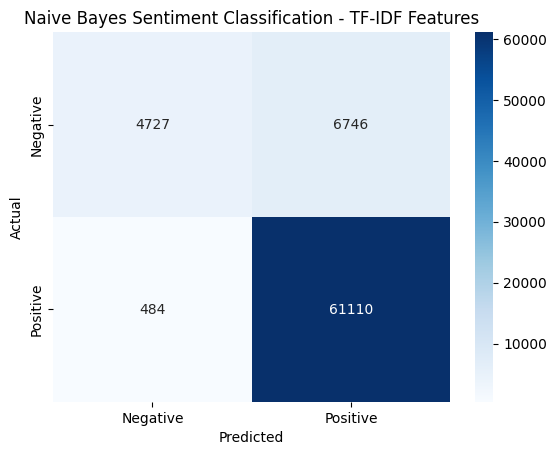

In [ ]:
#Visualization with heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Sentiment Classification - TF-IDF Features')
plt.show()

#Testing with new reviews
we try out fresh reviews to see how the model behaves on real user text.
We transform them using the same TF-IDF settings and check what sentiment the model assigns.

In [ ]:
# New reviews
new_reviews = [
    "I absolutely love this chips! Its taste is soo good.",
    "This is the worst experience I’ve ever had.",
    "It’s okay, not too bad but not great either.",
    "I’m very satisfied with the quality and performance.",
    "Totally disappointed, waste of money.",
]

# Transform using the same TF-IDF vectorizer used in training
new_tfidf = tfidf_vectorizer.transform(new_reviews)

# Predict
predictions = nb_model.predict(new_tfidf)

# Display results
for review, sentiment in zip(new_reviews, predictions):
    print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")


Review: I absolutely love this chips! Its taste is soo good.
Predicted Sentiment: positive

Review: This is the worst experience I’ve ever had.
Predicted Sentiment: negative

Review: It’s okay, not too bad but not great either.
Predicted Sentiment: negative

Review: I’m very satisfied with the quality and performance.
Predicted Sentiment: positive

Review: Totally disappointed, waste of money.
Predicted Sentiment: negative



## Summary
We built a sentiment classification pipeline using TF-IDF features and a Multinomial Naive Bayes model on Amazon food reviews.  
We trained, evaluated, and tested the model, achieving meaningful performance and demonstrating how NLP can be used to automatically classify customer opinions.